In [40]:
"""
Should contain code to evaluate predictions, initally on the tiny_dataset.json file, using the baseline bot's output
"""

"\nShould contain code to evaluate predictions, initally on the tiny_dataset.json file, using the baseline bot's output\n"

In [41]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
def load_predictions(path):
    with open(path) as f:
        raw = json.load(f)
    df = pd.DataFrame(raw)
    return df[df["prediction"].notna()].copy()

models = {}

if Path("baseline_predictions.json").exists():
    models["Baseline"] = load_predictions("baseline_predictions.json")
    print(f"Baseline:    {len(models['Baseline'])} predictions")

if Path("maxent_smm_predictions.json").exists():
    models["MaxEnt-SMM"] = load_predictions("maxent_smm_predictions.json")
    print(f"MaxEnt-SMM:  {len(models['MaxEnt-SMM'])} predictions")

if Path("maxent_smm_predictions_high.json").exists():
    models["MaxEnt-SMM High"] = load_predictions("maxent_smm_predictions_high.json")
    print(f"MaxEnt-SMM High:  {len(models['MaxEnt-SMM High'])} predictions")

assert models, "No prediction files found. Run run_baseline.ipynb or run_maxent_smm.ipynb first."

Baseline:    24 predictions
MaxEnt-SMM:  24 predictions
MaxEnt-SMM High:  24 predictions


In [43]:
def brier_score(preds, actuals):
    return float(np.mean((np.array(preds) - np.array(actuals)) ** 2))

def log_loss(preds, actuals, eps=1e-7):
    p = np.clip(preds, eps, 1 - eps)
    t = np.array(actuals)
    return float(-np.mean(t * np.log(p) + (1 - t) * np.log(1 - p)))

rows = []
for name, df in models.items():
    y_true = df["resolved_to"].tolist()
    y_pred = df["prediction"].tolist()
    rows.append({"Model": name, "Brier": brier_score(y_pred, y_true), "LogLoss": log_loss(y_pred, y_true), "N": len(df)})

# Market and naive baselines from any available df
ref_df = next(iter(models.values()))
mkt = ref_df[ref_df["market_price"].notna()]
if len(mkt):
    rows.append({"Model": "Market", "Brier": brier_score(mkt["market_price"], mkt["resolved_to"]), "LogLoss": log_loss(mkt["market_price"], mkt["resolved_to"]), "N": len(mkt)})

y_all = ref_df["resolved_to"].tolist()
rows.append({"Model": "Naive 50%", "Brier": brier_score([0.5]*len(y_all), y_all), "LogLoss": log_loss([0.5]*len(y_all), y_all), "N": len(y_all)})

metrics_df = pd.DataFrame(rows).set_index("Model")
metrics_df.style.format({"Brier": "{:.4f}", "LogLoss": "{:.4f}", "N": "{:.0f}"})

,Brier,LogLoss,N
Model,,,
Baseline,0.1489,0.4779,24
MaxEnt-SMM,0.2047,0.6016,24
MaxEnt-SMM High,0.1871,0.5645,24
Market,19685727.2818,8.4930,19
Naive 50%,0.2500,0.6931,24


AttributeError: 'DataFrame' object has no attribute 'tolist'

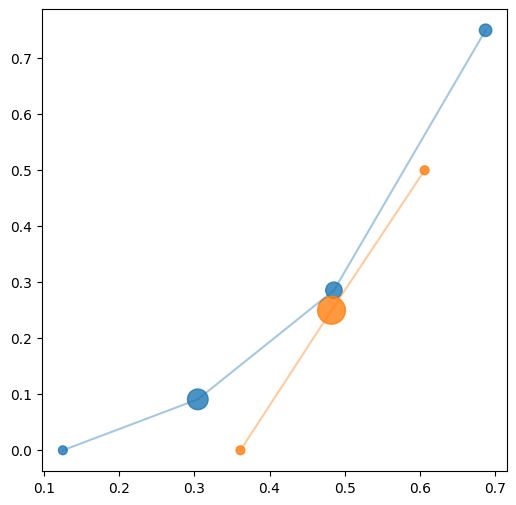

In [30]:
# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
bins = np.linspace(0, 1, 6)  # 5 bins

plot_items = list(models.items())
# Add market if available
mkt_rows = ref_df[ref_df["market_price"].notna()]
if len(mkt_rows):
    plot_items.append(("Market", mkt_rows.rename(columns={"market_price": "prediction"})))

for label, df in plot_items:
    preds = df["prediction"].tolist()
    actuals = df["resolved_to"].tolist()
    centers, freqs, counts = [], [], []
    for lo, hi in zip(bins, bins[1:]):
        mask = [(lo <= p < hi) for p in preds]
        if not any(mask):
            continue
        centers.append(np.mean([p for p, m in zip(preds, mask) if m]))
        freqs.append(np.mean([a for a, m in zip(actuals, mask) if m]))
        counts.append(sum(mask))
    ax.scatter(centers, freqs, s=[c * 20 for c in counts], label=label, alpha=0.8)
    ax.plot(centers, freqs, alpha=0.4)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Actual resolution rate")
ax.set_title("Calibration (dot size ∝ count)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [31]:
# Per-question comparison: worst predictions for each model
for name, df in models.items():
    df["sq_error"] = (df["prediction"] - df["resolved_to"]) ** 2
    print(f"\n--- {name} — worst 5 ---")
    cols = ["question", "prediction", "market_price", "resolved_to", "sq_error"]
    available = [c for c in cols if c in df.columns]
    display(df[available].sort_values("sq_error", ascending=False).head(5).style.format(
        {"prediction": "{:.1%}", "market_price": "{:.1%}", "sq_error": "{:.3f}"}
    ))


--- Baseline — worst 5 ---


,question,prediction,market_price,resolved_to,sq_error
19,"According to Wikipedia, will a vaccine have been developed for Marburg hemorrhagic fever (MHF) by 2026-02-08?",75.0%,nan%,0.000000,0.562
0,Will there be at least one podium sweep at the 2026 Winter Olympic Games?,35.0%,83.0%,1.000000,0.423
18,"According to Wikipedia, will R Praggnanandhaa have an Elo rating on 2026-02-08 that's at least 1% higher than on 2025-09-09T00:00:00Z?",60.0%,275800.0%,0.000000,0.360
2,"Will there be more 'Riots' in Finland for the 30 days before 2026-02-08 compared to the 30-day average of 'Riots' over the 360 days preceding 2025-09-09T00:00:00Z? e.g. If the forecast due date is 2024-01-01 and we have the following data: Date,'Riots' 2023-11-11,1 2023-10-10,2 to calculate the 30-day average of 'Riots' over the preceding 360 days, we’d have: (1+2)/12=0.25. In this example, for the question to resolve positively, 1 or more 'Riots' would need to occur in the 30 days leading up to the resolution.",40.0%,0.0%,0.000000,0.160
12,Will the discount rate for the Federal Reserve's primary credit discount window program have increased by 2026-02-08 as compared to its value on 2025-09-09T00:00:00Z?,40.0%,375.0%,0.000000,0.160



--- MaxEnt-SMM — worst 5 ---


,question,prediction,market_price,resolved_to,sq_error
9,"Will there be more than ten times as many 'Battles' in Belarus for the 30 days before {resolution_date} compared to one plus the 30-day average of 'Battles' over the 360 days preceding {forecast_due_date}? e.g. If the forecast due date is 2024-01-01 and we have the following data: Date,'Battles' 2023-11-11,1 2023-10-10,2 to calculate one plus the 30-day average of 'Battles' over the preceding 360 days, we’d have: 1+(1+2)/12=1.25. In this example, for the question to resolve positively, 13 (10 x 1.25) or more 'Battles' would need to occur in the 30 days leading up to the resolution.",60.4%,108.3%,0.000000,0.364
14,"According to Wikipedia, will Vaishali Rameshbabu have a FIDE ranking on {resolution_date} as high or higher than their ranking on {forecast_due_date}?",41.1%,1600.0%,1.000000,0.347
6,"Will there be more than ten times as many fatalities in Burkina Faso for the 30 days before {resolution_date} compared to one plus the 30-day average of fatalities over the 360 days preceding {forecast_due_date}? e.g. If the forecast due date is 2024-01-01 and we have the following data: Date,fatalities 2023-11-11,1 2023-10-10,2 to calculate one plus the 30-day average of fatalities over the preceding 360 days, we’d have: 1+(1+2)/12=1.25. In this example, for the question to resolve positively, 13 (10 x 1.25) or more fatalities would need to occur in the 30 days leading up to the resolution.",52.1%,41066.7%,0.000000,0.271
23,"According to Wikipedia, will a vaccine have been developed for Mycoplasma pneumonia by {resolution_date}?",50.6%,nan%,0.000000,0.256
22,"According to Wikipedia, will a vaccine have been developed for AIDS (acquired immunodeficiency syndrome) by {resolution_date}?",50.3%,nan%,0.000000,0.253


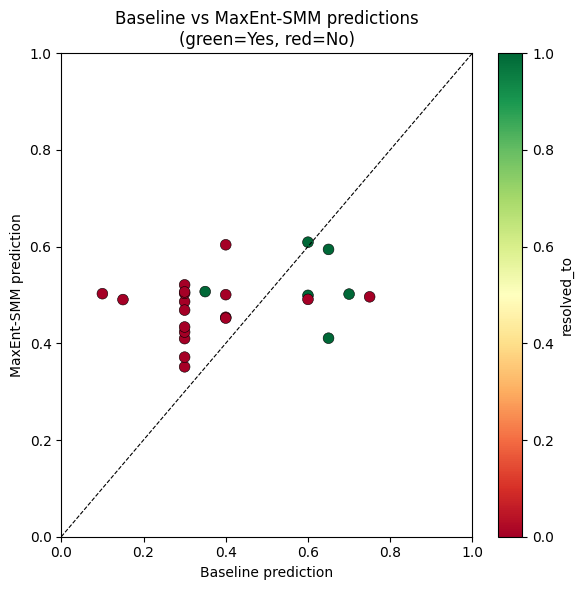

Agreement (|diff| < 0.1): 25.0%


In [32]:
# If both models are available: scatter plot of predictions vs each other
if "Baseline" in models and "MaxEnt-SMM" in models:
    merged = models["Baseline"][["id", "question", "resolved_to", "prediction"]].merge(
        models["MaxEnt-SMM"][["id", "prediction"]],
        on="id", suffixes=("_baseline", "_smm")
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(
        merged["prediction_baseline"], merged["prediction_smm"],
        c=merged["resolved_to"], cmap="RdYlGn", vmin=0, vmax=1,
        edgecolors="k", linewidths=0.4, s=60
    )
    plt.colorbar(sc, label="resolved_to")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("Baseline prediction")
    ax.set_ylabel("MaxEnt-SMM prediction")
    ax.set_title("Baseline vs MaxEnt-SMM predictions\n(green=Yes, red=No)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(f"Agreement (|diff| < 0.1): {(abs(merged['prediction_baseline'] - merged['prediction_smm']) < 0.1).mean():.1%}")